# Sklearn: Model Evaluation & Tuning
Building a model is 20% of the work. Evaluating and tuning it is 80%.*

## What is Model Evaluation & Tuning?
Training a model is only the first step. Before deploying it you need to:

1. **Evaluate honestly** — measure real performance on data the model has never seen
2. **Diagnose problems** — is it underfitting (too simple) or overfitting (memorizing training data)?
3. **Tune hyperparameters** — systematically search for the settings that maximize performance

This notebook covers the core tools for all three steps:

| Topic | Tool |
|-------|------|
| Honest evaluation | Cross-Validation (`cross_val_score`, `cross_validate`) |
| Diagnosing fit | Learning Curves (`learning_curve`) |
| Hyperparameter search | `GridSearchCV`, `RandomizedSearchCV` |
| Threshold decisions | Precision / Recall tradeoff |

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data loaded")

Data loaded


## 1. Cross-Validation — The Right Way to Evaluate
A single train/test split is unreliable — you might get lucky or unlucky depending on which samples end up in each set. **K-Fold Cross-Validation** removes this randomness by evaluating the model on every sample exactly once.

**How 5-Fold CV works:**
1. Split the data into 5 equal folds
2. Train on 4 folds, test on the remaining 1
3. Rotate the held-out fold — repeat 5 times
4. Average the 5 scores

**What the results tell you:**
- **Mean score** — the model's expected performance on genuinely unseen data
- **Std deviation** — how stable the model is; low std = consistent across different splits, high std = sensitive to which data it sees
- **Train vs Test gap** — if train score is consistently much higher than test score, the model is overfitting

In [2]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42))
])

# 5-fold cross-validation
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

print("5-Fold CV Results:")
for i, score in enumerate(cv_scores, 1):
    bar = '|' * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")
print(f"\n  Mean +/- Std: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"  Low std = stable model" if cv_scores.std() < 0.02 else "  High std = unstable across folds")

5-Fold CV Results:
  Fold 1: 0.9825  |||||||||||||||||||||||||||||||||||||||
  Fold 2: 0.9825  |||||||||||||||||||||||||||||||||||||||
  Fold 3: 0.9737  ||||||||||||||||||||||||||||||||||||||
  Fold 4: 0.9737  ||||||||||||||||||||||||||||||||||||||
  Fold 5: 0.9912  |||||||||||||||||||||||||||||||||||||||

  Mean +/- Std: 0.9807 +/- 0.0065
  Low std = stable model


In [3]:
# Try multiple metrics at once
from sklearn.model_selection import cross_validate

results = cross_validate(pipe, X, y, cv=5,
    scoring=['accuracy', 'roc_auc', 'f1'],
    return_train_score=True)

metrics = ['accuracy', 'roc_auc', 'f1']
print(f"{'Metric':<15} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 42)
for m in metrics:
    train = results[f'train_{m}'].mean()
    test  = results[f'test_{m}'].mean()
    gap   = train - test
    flag  = " ← overfitting?" if gap > 0.05 else ""
    print(f"{m:<15} {train:>8.4f} {test:>8.4f} {gap:>8.4f}{flag}")

Metric             Train     Test      Gap
------------------------------------------
accuracy          0.9895   0.9807   0.0088
roc_auc           0.9977   0.9952   0.0025
f1                0.9916   0.9848   0.0069


## 2. Learning Curves — Diagnose Bias vs Variance
A learning curve plots model performance as the **training set size grows**. It reveals whether a model is suffering from **high bias** (underfitting) or **high variance** (overfitting) — which tells you what to fix next.

**How to read the curve:**

| Pattern | Diagnosis | Fix |
|---------|-----------|-----|
| Both lines converge high, small gap | Good fit | Model is ready |
| Large gap — train high, val low | High variance / overfitting | More data, regularization, simpler model |
| Both lines converge low | High bias / underfitting | More complex model, more features |
| Val score still rising at the end | Data-limited | Collect more training data |

**Bias vs Variance:**
- **Bias** — error from wrong assumptions; the model is too simple to capture the pattern
- **Variance** — error from sensitivity to training data; the model memorizes noise instead of learning the signal

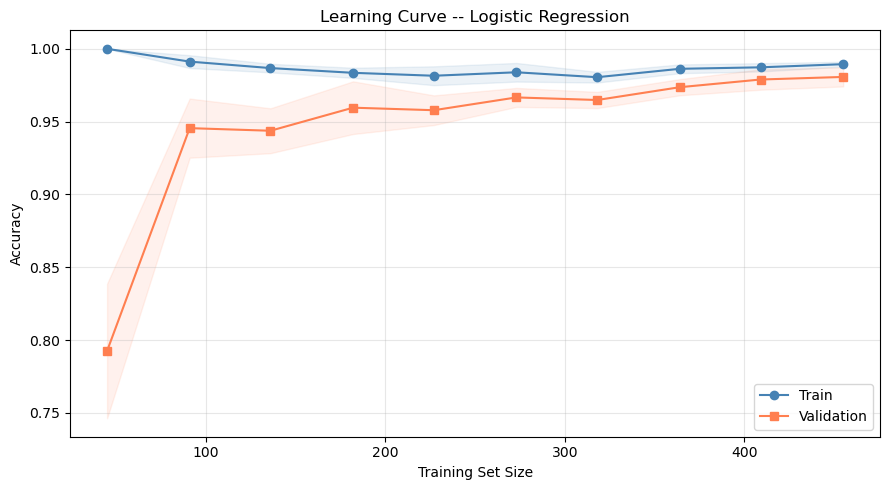

Reading the curve:
  Both lines converge high  => good model fit
  Large gap between lines   => overfitting (regularize or get more data)
  Both lines converge low   => underfitting (try a more complex model)


In [4]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_mean, 's-', color='coral', label='Validation')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='coral')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve -- Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Reading the curve:")
print("  Both lines converge high  => good model fit")
print("  Large gap between lines   => overfitting (regularize or get more data)")
print("  Both lines converge low   => underfitting (try a more complex model)")

## 3. Hyperparameter Tuning — GridSearchCV
**Hyperparameters** are settings you choose before training — unlike model parameters (weights), which are learned from the data. Examples: `n_estimators` in Random Forest, `C` in Logistic Regression, `max_depth` in Decision Tree.

**GridSearchCV** exhaustively tries every combination of hyperparameter values you specify, evaluating each combination with cross-validation, then returns the best one automatically.

**How it works:**
1. Define a grid of candidate values for each hyperparameter
2. For every combination in the grid, run K-fold CV and record the average score
3. Return the combination with the highest CV score

**Cost:** `n_combinations × n_folds` model fits — can be slow when the grid is large.
In pipelines, hyperparameters are referenced as `stepname__param` (e.g. `model__max_depth`).

In [6]:
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define the grid — parameters are prefixed with 'model__'
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth':    [None, 5, 10],
    'model__min_samples_split': [2, 5],
}

print(f"Total combinations to try: {3*3*2} × 5 folds = {3*3*2*5} fits")
print("Running GridSearchCV...")

grid_search = GridSearchCV(
    pipe_rf, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, grid_search.predict_proba(X_test)[:,1]):.4f}")

Total combinations to try: 18 × 5 folds = 90 fits
Running GridSearchCV...
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.9889
Test ROC-AUC: 0.9934


## 4. RandomizedSearchCV — Faster Alternative
When the hyperparameter grid is large, **GridSearchCV becomes too slow** — the number of combinations explodes. RandomizedSearchCV samples a fixed number of random combinations instead, and in practice finds a nearly-as-good result in a fraction of the time.

**Why it works:** In large hyperparameter spaces, not all parameters matter equally. Random sampling covers the space efficiently without evaluating every single point.

**GridSearchCV vs RandomizedSearchCV:**

| | GridSearchCV | RandomizedSearchCV |
|--|-------------|-------------------|
| Tries | All combinations | `n_iter` random combinations |
| Result | Best in the defined grid | Near-optimal, probabilistic |
| Speed | Slow on large grids | Fast — fixed `n_iter` fits |
| Best when | Small grid (< ~50 combos) | Large grid or continuous distributions |

You can also pass **distributions** (e.g. `scipy.stats.randint`) instead of fixed lists, letting it sample from a continuous range.

In [7]:
from scipy.stats import randint

param_dist = {
    'model__n_estimators':     randint(50, 300),
    'model__max_depth':        [None, 3, 5, 10, 20],
    'model__min_samples_split': randint(2, 20),
    'model__max_features':     ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(
    pipe_rf, param_dist,
    n_iter=20,           # try 20 random combos (instead of all)
    cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, random_search.predict_proba(X_test)[:,1]):.4f}")
print()
print("RandomizedSearchCV vs GridSearchCV:")
print("  Grid: exhaustive, best result, slow on large grids")
print("  Random: faster, nearly as good, better for large search spaces")

Best params: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_split': 7, 'model__n_estimators': 179}
Best CV ROC-AUC: 0.9898
Test ROC-AUC: 0.9927

RandomizedSearchCV vs GridSearchCV:
  Grid: exhaustive, best result, slow on large grids
  Random: faster, nearly as good, better for large search spaces


## 5. Precision vs Recall Tradeoff
By default, a classifier predicts class 1 when probability > 0.5. But you can **shift this threshold** to trade precision for recall depending on what mistakes are more costly in your problem.

**Precision** = TP / (TP + FP) — of everything the model flagged positive, how many were actually positive? Penalizes false alarms.

**Recall** = TP / (TP + FN) — of all actual positives, how many did the model catch? Penalizes missed cases.

**The tradeoff:**
- Lowering the threshold → catches more true positives (higher recall) but also more false alarms (lower precision)
- Raising the threshold → fewer false alarms (higher precision) but more missed cases (lower recall)

**F1 score** = harmonic mean of precision and recall — useful when you want to balance both.

| Use case | Priority | Direction |
|----------|----------|-----------|
| Cancer detection, fraud | Recall — missing a case is costly | Lower the threshold |
| Spam filter, ad targeting | Precision — false alarms annoy users | Raise the threshold |
| Balanced importance | F1 score | Keep default 0.5 |

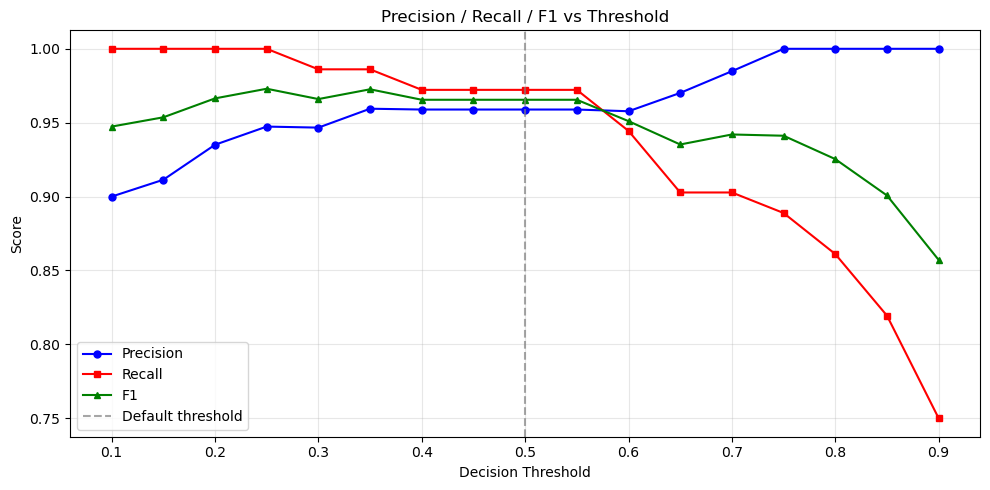

Key decisions:
  High precision needed (spam filter)   => raise threshold => fewer false positives
  High recall needed (cancer detection) => lower threshold => fewer false negatives


In [8]:
best_model = grid_search.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, 'b-o', ms=5, label='Precision')
plt.plot(thresholds, recalls, 'r-s', ms=5, label='Recall')
plt.plot(thresholds, f1s, 'g-^', ms=5, label='F1')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold')
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Key decisions:")
print("  High precision needed (spam filter)   => raise threshold => fewer false positives")
print("  High recall needed (cancer detection) => lower threshold => fewer false negatives")

## Key Takeaways

- **Cross-validation** — always prefer CV over a single split; mean gives expected performance, std tells you stability
- **Learning curves** — diagnose before tuning; fix underfitting or overfitting first, then tune hyperparameters
- **GridSearchCV** — best result for small grids; cost = n_combinations × n_folds fits
- **RandomizedSearchCV** — nearly as good, much faster; use for large grids or continuous distributions
- **Precision vs Recall** — choose based on what mistake is more costly in your problem:
  - Miss a cancer → use recall (lower threshold)
  - Spam false alarm → use precision (raise threshold)
  - Both matter equally → use F1
- **Pipeline + `stepname__param` syntax** — always wrap scaler + model in a pipeline to prevent data leakage during CV